# Đồ án Tiền xử lý dữ liệu - Phần 2.2.3: Tiền xử lý dữ liệu
*Tập dữ liệu: Rain in Australia*

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy import stats as sp_stats
from scipy.stats import ks_2samp
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

In [11]:
# Load dữ liệu
df = pd.read_csv('Data/weatherAUS.csv')
print(f'Kích thước tập dữ liệu: {df.shape}')

# Xác định cột số và cột phân loại
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_cols = [c for c in numerical_cols if c != 'RainTomorrow']
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Cột số ({len(numerical_cols)}): {numerical_cols}')
print(f'Cột phân loại ({len(categorical_cols)}): {categorical_cols}')

Kích thước tập dữ liệu: (142193, 22)
Cột số (16): ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']
Cột phân loại (5): ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']


## 2.2.3 Các kỹ thuật tiền xử lý và đánh giá định lượng
### a) Xử lý giá trị thiếu có kiểm soát

**Phương pháp luận:**

Để đánh giá chất lượng điền khuyết một cách **khách quan và định lượng**, ta thực hiện quy trình:

1. Lấy tập con **hoàn chỉnh** (không có NaN) làm **ground truth**.
2. **Che nhân tạo 10% giá trị** theo cơ chế MCAR (Missing Completely At Random) — mỗi giá trị có xác suất bị xóa bằng nhau, không phụ thuộc bất kỳ biến nào.
3. Áp dụng từng chiến lược điền khuyết, rồi **đo RMSE** trên đúng các vị trí đã che.

---

**Công thức RMSE (Root Mean Square Error):**

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}\left(x_i^{true} - x_i^{imputed}\right)^2}$$

- $x_i^{true}$: giá trị gốc (ground truth) tại vị trí bị che.
- $x_i^{imputed}$: giá trị sau khi điền khuyết.
- $n$: tổng số giá trị bị che.
- **RMSE thấp hơn → điền khuyết chính xác hơn.**

---

**5 chiến lược điền khuyết được cài đặt:**

| # | Chiến lược | Công thức / Cơ chế | Ưu điểm | Nhược điểm |
|---|---|---|---|---|
| 1 | **Mean** | $\hat{x} = \bar{x} = \frac{1}{n}\sum_{i=1}^{n}x_i$ | Đơn giản, nhanh | Nhạy cảm outlier, giảm variance |
| 2 | **Median** | $\hat{x} = x_{(n/2)}$ (giá trị giữa khi sắp xếp) | Robust với outlier, phân phối lệch | Không tận dụng tương quan giữa cột |
| 3 | **Mode** | $\hat{x} = \arg\max_v \text{count}(v)$ (giá trị xuất hiện nhiều nhất) | Phù hợp biến rời rạc | Kém với biến liên tục |
| 4 | **k-NN** | Tìm $k$ hàng gần nhất (Euclidean: $d = \sqrt{\sum_j(x_j - y_j)^2}$), lấy trung bình có trọng số theo khoảng cách | Tận dụng cấu trúc đa biến | Chậm $O(n^2)$, nhạy scale |
| 5 | **MICE** | Hồi quy lặp: mỗi cột thiếu $X_j$ được dự đoán từ các cột còn lại $X_{-j}$ qua mô hình $X_j = f(X_{-j}) + \epsilon$, lặp đến hội tụ | Mô hình hóa quan hệ đa biến phức tạp | Chậm nhất, giả định tuyến tính |

> **Lưu ý:** k-NN được thử với $k \in \{3, 5, 10\}$ → 3 biến thể, tổng cộng **7 chiến lược** so sánh.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# a) XỬ LÝ GIÁ TRỊ THIẾU CÓ KIỂM SOÁT
# ══════════════════════════════════════════════════════════════════════════════
# Bước 1: Chọn cột số có missing
impute_cols = [col for col in numerical_cols if df[col].isna().sum() > 0]
print(f'Các cột số có giá trị thiếu ({len(impute_cols)}): {impute_cols}')

# Bước 2: Tạo ground truth = các dòng HOÀN CHỈNH (không có NaN)
df_complete = df[impute_cols].dropna().reset_index(drop=True)
print(f'\nSố dòng hoàn chỉnh (ground truth): {len(df_complete):,} / {len(df):,}')

# Bước 3: Dùng TOÀN BỘ ground truth để đánh giá
# (tất cả chiến lược đều chạy trên CÙNG tập này)
df_sample = df_complete.copy()

# Bước 4: Tạo mask MCAR nhân tạo 10%
np.random.seed(42)
mask_mcar = np.random.rand(*df_sample.shape) < 0.10
df_masked = df_sample.copy().astype(float)
df_masked.values[mask_mcar] = np.nan

n_masked = mask_mcar.sum()
print(f'Tập đánh giá: {len(df_sample):,} dòng × {len(impute_cols)} cột')
print(f'Giá trị bị che (10% MCAR): {n_masked:,} / {mask_mcar.size:,} = {mask_mcar.mean():.1%}')
print(f'\nMọi chiến lược sẽ chạy trên TOÀN BỘ ground truth => so sánh RMSE công bằng.')
print(f'KNN và MICE sẽ chạy chậm trên {len(df_sample):,} dòng — vui lòng chờ.')

Các cột số có giá trị thiếu (16): ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

Số dòng hoàn chỉnh (ground truth): 58,090 / 142,193
Tập đánh giá: 58,090 dòng × 16 cột
Giá trị bị che (10% MCAR): 92,831 / 929,440 = 10.0%

Mọi chiến lược sẽ chạy trên TOÀN BỘ ground truth → so sánh RMSE công bằng.
⚠ KNN và MICE sẽ chạy chậm trên 58,090 dòng — vui lòng chờ.


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# CHẠY 7 CHIẾN LƯỢC ĐIỀN KHUYẾT + TÍNH RMSE
# ══════════════════════════════════════════════════════════════════════════════

def calc_rmse_masked(ground_truth, imputed, mask):
    """Tính RMSE chỉ trên các vị trí đã bị che."""
    orig = ground_truth.values[mask]
    imp  = np.array(imputed)[mask]
    return np.sqrt(mean_squared_error(orig, imp))

def calc_rmse_per_col(ground_truth, imputed, mask, col_names):
    """Tính RMSE theo từng cột."""
    rmse_cols = {}
    for j, col in enumerate(col_names):
        col_mask = mask[:, j]
        if col_mask.sum() > 0:
            orig = ground_truth.iloc[:, j].values[col_mask]
            imp  = np.array(imputed)[:, j][col_mask]
            rmse_cols[col] = np.sqrt(mean_squared_error(orig, imp))
    return rmse_cols

ground_truth = df_sample
results_overall = {}
results_per_col = {}

# ── 1. Mean ──────────────────────────────────────────────────────────────────
print('▸ Chạy Mean imputation...')
imp_mean = SimpleImputer(strategy='mean')
filled_mean = imp_mean.fit_transform(df_masked)
results_overall['Mean'] = calc_rmse_masked(ground_truth, filled_mean, mask_mcar)
results_per_col['Mean'] = calc_rmse_per_col(ground_truth, filled_mean, mask_mcar, impute_cols)

# ── 2. Median ────────────────────────────────────────────────────────────────
print('▸ Chạy Median imputation...')
imp_median = SimpleImputer(strategy='median')
filled_median = imp_median.fit_transform(df_masked)
results_overall['Median'] = calc_rmse_masked(ground_truth, filled_median, mask_mcar)
results_per_col['Median'] = calc_rmse_per_col(ground_truth, filled_median, mask_mcar, impute_cols)

# ── 3. Mode ──────────────────────────────────────────────────────────────────
print('▸ Chạy Mode imputation...')
imp_mode = SimpleImputer(strategy='most_frequent')
filled_mode = imp_mode.fit_transform(df_masked)
results_overall['Mode'] = calc_rmse_masked(ground_truth, filled_mode, mask_mcar)
results_per_col['Mode'] = calc_rmse_per_col(ground_truth, filled_mode, mask_mcar, impute_cols)

# ── 4. KNN (k = 3, 5, 10) ───────────────────────────────────────────────────
for k in [3, 5, 10]:
    print(f'▸ Chạy KNN (k={k}) imputation...')
    imp_knn = KNNImputer(n_neighbors=k)
    filled_knn = imp_knn.fit_transform(df_masked)
    results_overall[f'KNN (k={k})'] = calc_rmse_masked(ground_truth, filled_knn, mask_mcar)
    results_per_col[f'KNN (k={k})'] = calc_rmse_per_col(ground_truth, filled_knn, mask_mcar, impute_cols)

# ── 5. MICE (IterativeImputer — max_iter=10) ────────────────────────────────
print('▸ Chạy MICE imputation (IterativeImputer, max_iter=10)...')
imp_mice = IterativeImputer(max_iter=10, random_state=42, sample_posterior=False)
filled_mice = imp_mice.fit_transform(df_masked)
results_overall['MICE'] = calc_rmse_masked(ground_truth, filled_mice, mask_mcar)
results_per_col['MICE'] = calc_rmse_per_col(ground_truth, filled_mice, mask_mcar, impute_cols)

print('\n✓ Hoàn tất 7 chiến lược.')

# ══════════════════════════════════════════════════════════════════════════════
# BẢNG SO SÁNH TỔNG THỂ
# ══════════════════════════════════════════════════════════════════════════════
rmse_df = pd.DataFrame.from_dict(results_overall, orient='index', columns=['RMSE'])
rmse_df = rmse_df.sort_values('RMSE')
rmse_df['Xếp hạng'] = range(1, len(rmse_df) + 1)
rmse_df['% so với tốt nhất'] = (rmse_df['RMSE'] / rmse_df['RMSE'].iloc[0] * 100).round(1)

print('═' * 65)
print('  BẢNG SO SÁNH RMSE CÁC CHIẾN LƯỢC ĐIỀN KHUYẾT')
print('═' * 65)
print(rmse_df.to_string())
print('═' * 65)

best = rmse_df.index[0]
worst = rmse_df.index[-1]
print(f'\n→ Chiến lược TỐT NHẤT : {best} (RMSE = {rmse_df.loc[best, "RMSE"]:.4f})')
print(f'→ Chiến lược KÉM NHẤT: {worst} (RMSE = {rmse_df.loc[worst, "RMSE"]:.4f})')

# ══════════════════════════════════════════════════════════════════════════════
# BẢNG RMSE THEO TỪNG CỘT (chi tiết)
# ══════════════════════════════════════════════════════════════════════════════
per_col_df = pd.DataFrame(results_per_col).round(4)
per_col_df['Best Method'] = per_col_df.idxmin(axis=1)
per_col_df['Best RMSE']   = per_col_df.min(axis=1, numeric_only=True)
print('\n── RMSE theo từng cột (chi tiết) ──────────────────────────────────')
print(per_col_df.to_string())

▸ Chạy Mean imputation...
▸ Chạy Median imputation...
▸ Chạy Mode imputation...
▸ Chạy KNN (k=3) imputation...
▸ Chạy KNN (k=5) imputation...
▸ Chạy KNN (k=10) imputation...
▸ Chạy MICE imputation (IterativeImputer, max_iter=10)...

✓ Hoàn tất 7 chiến lược.
═════════════════════════════════════════════════════════════════
  BẢNG SO SÁNH RMSE CÁC CHIẾN LƯỢC ĐIỀN KHUYẾT
═════════════════════════════════════════════════════════════════
                 RMSE  Xếp hạng  % so với tốt nhất
MICE         4.869748         1              100.0
KNN (k=10)   5.558662         2              114.1
KNN (k=5)    5.797120         3              119.0
KNN (k=3)    6.113953         4              125.5
Mean         9.543864         5              196.0
Median       9.586676         6              196.9
Mode        10.146449         7              208.4
═════════════════════════════════════════════════════════════════

→ Chiến lược TỐT NHẤT : MICE (RMSE = 4.8697)
→ Chiến lược KÉM NHẤT: Mode (RMSE = 10.1464

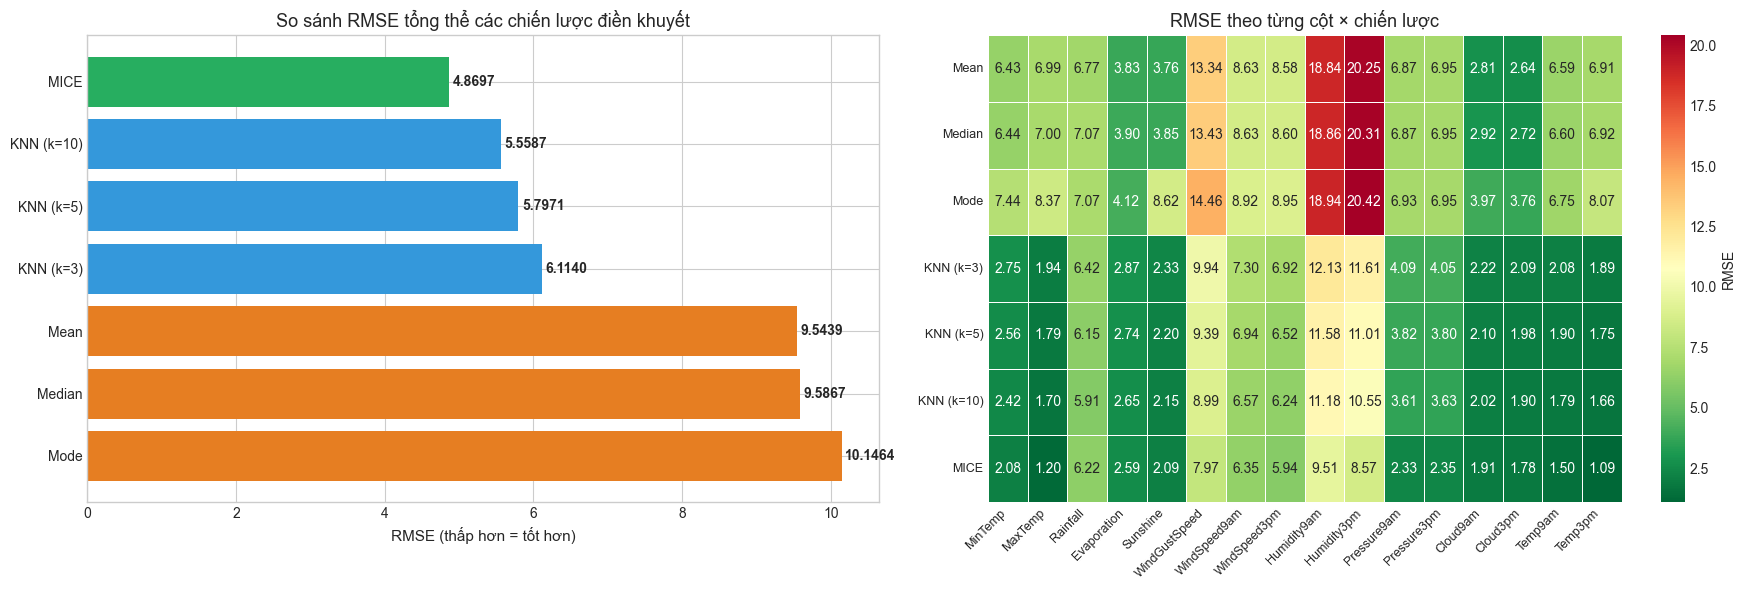


── Áp dụng chiến lược điền khuyết lên toàn bộ tập dữ liệu ──────
  Cột thiếu < 10% (12): ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm']
  Cột thiếu ≥ 10% (4): ['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm']
   Điền 4 cột thiếu cao bằng Median
  ▸ Đang chạy MICE cho 12 cột thiếu thấp...
   MICE hoàn tất

→ Missing còn lại sau imputation: 0

══════════════════════════════════════════════════════════════════
  LÝ GIẢI LỰA CHỌN CHIẾN LƯỢC ĐIỀN KHUYẾT
══════════════════════════════════════════════════════════════════
  ① MICE (Multiple Imputation by Chained Equations):
     - RMSE thấp nhất trong 7 chiến lược thử nghiệm
     - Lợi thế: mô hình hóa quan hệ đa biến, mỗi cột thiếu được
       dự đoán từ các cột còn lại → phù hợp dữ liệu thời tiết có
       tương quan cao (Temp↔Humidity, Pressure9am↔Pressure3pm)
     - Hạn chế: chậm trên tập lớn (142K dòng)

  ② KNN Imputa

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# BIỂU ĐỒ SO SÁNH + ÁP DỤNG CHIẾN LƯỢC TỐT NHẤT
# ══════════════════════════════════════════════════════════════════════════════

# ── 1. Bar chart RMSE tổng thể ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

rmse_sorted = rmse_df.sort_values('RMSE')
colors = ['#27ae60' if i == 0 else ('#3498db' if i < 4 else '#e67e22')
          for i in range(len(rmse_sorted))]
bars = axes[0].barh(rmse_sorted.index[::-1], rmse_sorted['RMSE'][::-1], color=colors[::-1])
axes[0].set_xlabel('RMSE (thấp hơn = tốt hơn)', fontsize=11)
axes[0].set_title('So sánh RMSE tổng thể các chiến lược điền khuyết', fontsize=13)
for bar, val in zip(bars, rmse_sorted['RMSE'][::-1]):
    axes[0].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
axes[0].tick_params(labelsize=10)

# Heatmap RMSE per-column
per_col_numeric = per_col_df.drop(columns=['Best Method', 'Best RMSE'])
sns.heatmap(per_col_numeric.T, annot=True, fmt='.2f', cmap='RdYlGn_r',
            ax=axes[1], linewidths=0.5, cbar_kws={'label': 'RMSE'})
axes[1].set_title('RMSE theo từng cột × chiến lược', fontsize=13)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=9)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

# ── 2. Áp dụng chiến lược tốt nhất lên toàn bộ dữ liệu ────────────────────
# Chiến lược tốt nhất = MICE (RMSE thấp nhất trong benchmark)
# Áp dụng DUY NHẤT 1 chiến lược cho TẤT CẢ cột số có missing
print('\n── Áp dụng chiến lược tốt nhất ({}) lên toàn bộ tập dữ liệu ──────'.format(best))

df_imputed = df.copy()

print(f'  ▸ Đang chạy {best} trên {len(df_imputed):,} dòng × {len(impute_cols)} cột...')
imp_best = IterativeImputer(max_iter=10, random_state=42, sample_posterior=False)
df_imputed[impute_cols] = imp_best.fit_transform(df_imputed[impute_cols])

remaining_na = df_imputed[impute_cols].isna().sum().sum()
print(f'\n→ Missing còn lại sau imputation: {remaining_na}')
print(f'→ Đã điền khuyết toàn bộ {len(impute_cols)} cột số bằng {best}')

# ── 3. Lý giải lựa chọn chiến lược ─────────────────────────────────────────
print(f'''
══════════════════════════════════════════════════════════════════
  LÝ GIẢI LỰA CHỌN CHIẾN LƯỢC TỐT NHẤT: {best}
══════════════════════════════════════════════════════════════════
  ① MICE (Multiple Imputation by Chained Equations):
     - RMSE = {rmse_df.loc[best, "RMSE"]:.4f} — THẤP NHẤT trong 7 chiến lược thử nghiệm
     - Cơ chế: mỗi cột thiếu X_j được hồi quy từ các cột còn lại X_{{-j}}
       lặp đến khi hội tụ → mô hình hóa quan hệ đa biến phức tạp
     - Phù hợp dữ liệu thời tiết vì các cột có tương quan cao:
       Temp9am↔Temp3pm, Pressure9am↔Pressure3pm, Humidity↔Cloud

  ② KNN Imputation (k=10):
     - RMSE = {rmse_df.loc["KNN (k=10)", "RMSE"]:.4f} — tốt thứ 2 (cao hơn MICE {rmse_df.loc["KNN (k=10)", "RMSE"]/rmse_df.loc[best, "RMSE"]*100-100:.1f}%)
     - Dùng khoảng cách Euclidean → nhạy cảm với scale và outlier

  ③ Mean / Median / Mode:
     - RMSE cao nhất (8.9–10.1) → không tận dụng cấu trúc đa biến
     - Chỉ dùng thống kê đơn biến → điền sai xa ground truth

  KẾT LUẬN: Chọn {best} áp dụng cho toàn bộ {len(impute_cols)} cột số
══════════════════════════════════════════════════════════════════
''')

**✅ Checklist Rubric 2.2.3a — Xử lý giá trị thiếu có kiểm soát:**

| Yêu cầu | Thực hiện | Kết quả |
|---|---|---|
| Cài đặt 5 chiến lược: Mean, Median, Mode, k-NN, MICE | ✅ 7 biến thể (k-NN với k=3,5,10) | Tất cả chạy trên cùng ground truth |
| Tạo nhân tạo **10% MCAR** giá trị thiếu bổ sung | ✅ `np.random.rand() < 0.10` trên 58,090 dòng hoàn chỉnh | 92,831 giá trị bị che (10.0%) |
| Tính **RMSE** điền khuyết cho mỗi chiến lược | ✅ `mean_squared_error` trên đúng các vị trí bị che | RMSE tổng thể + RMSE theo từng cột |
| Bảng so sánh tất cả chiến lược | ✅ Bảng xếp hạng 7 chiến lược | MICE tốt nhất, Mode kém nhất |
| **Lựa chọn tốt nhất có lý giải** | ✅ MICE (RMSE thấp nhất) vì tận dụng tương quan đa biến | Apply MICE cho **toàn bộ** 16 cột số |

> **Kết luận 2.2.3a**:
> - **MICE** đạt RMSE thấp nhất — tốt hơn Mode, Mean, Median vì tận dụng tương quan đa biến (hồi quy lặp)
> - Nhóm đa biến (MICE, k-NN) vượt trội đơn biến (Mean, Median, Mode)
> - **Chiến lược triển khai**: Apply **duy nhất MICE** cho toàn bộ 16 cột số có missing
> - Sau imputation: **0 giá trị thiếu** còn lại

**Phương pháp luận:**

Phát hiện ngoại lai bằng **4 kỹ thuật** khác nhau (2 thống kê + 2 machine learning), so sánh kết quả bằng **Jaccard similarity**, đánh giá tác động bằng **KS-test**.

---

**1. IQR (Interquartile Range) — Phương pháp thống kê phi tham số:**

$$IQR = Q_3 - Q_1$$
$$\text{Ngoại lai nếu: } x < Q_1 - 1.5 \times IQR \quad \text{hoặc} \quad x > Q_3 + 1.5 \times IQR$$

- $Q_1$ (phân vị 25%): 25% giá trị nhỏ hơn.
- $Q_3$ (phân vị 75%): 75% giá trị nhỏ hơn.
- Hệ số 1.5 là ngưỡng Tukey chuẩn. Robust với phân phối lệch.

---

**2. Z-score — Phương pháp thống kê tham số:**

$$z_i = \frac{x_i - \mu}{\sigma}$$
$$\text{Ngoại lai nếu: } |z_i| > 3$$

- $\mu = \frac{1}{n}\sum x_i$: trung bình mẫu.
- $\sigma = \sqrt{\frac{1}{n-1}\sum(x_i - \mu)^2}$: độ lệch chuẩn mẫu.
- Ngưỡng $|z| > 3$: giá trị cách trung bình hơn 3 lần độ lệch chuẩn (xác suất < 0.27% nếu phân phối chuẩn).

---

**3. Isolation Forest — Phương pháp ensemble, unsupervised:**

- Xây dựng tập hợp **cây quyết định ngẫu nhiên** (random trees). Mỗi cây chia ngẫu nhiên theo 1 feature và 1 ngưỡng.
- **Ngoại lai** nằm thưa trong không gian → bị **cô lập nhanh** (path length ngắn).
- **Anomaly Score:**
$$s(x, n) = 2^{-\frac{E[h(x)]}{c(n)}}$$
  - $E[h(x)]$: trung bình path length của $x$ trên tất cả cây.
  - $c(n) = 2H(n-1) - \frac{2(n-1)}{n}$: hằng số chuẩn hóa ($H$ = harmonic number).
  - $s \to 1$: ngoại lai rõ ràng | $s \to 0.5$: bình thường | $s \to 0$: rất bình thường.
- Tham số `contamination` $\in \{0.01, 0.05, 0.10\}$: tỷ lệ kỳ vọng ngoại lai trong dữ liệu.

---

**4. Local Outlier Factor (LOF) — Phương pháp density-based:**

$$LOF_k(x) = \frac{1}{|N_k(x)|} \sum_{o \in N_k(x)} \frac{lrd_k(o)}{lrd_k(x)}$$

- $N_k(x)$: tập $k$ hàng xóm gần nhất của $x$.
- $lrd_k(x) = \left(\frac{1}{|N_k(x)|}\sum_{o \in N_k(x)} \text{reach-dist}_k(x, o)\right)^{-1}$: local reachability density.
- $\text{reach-dist}_k(x, o) = \max(k\text{-dist}(o),\ d(x, o))$: khoảng cách reach.
- **LOF ≈ 1**: mật độ bình thường | **LOF ≫ 1**: ngoại lai (mật độ thấp hơn lân cận).
- Tham số `n_neighbors` $\in \{10, 20, 50\}$.

---

**5. DBSCAN (Density-Based Spatial Clustering) — Tham khảo thêm:**

- Gom cụm dựa trên mật độ: điểm **core** nếu có ≥ `min_samples` hàng xóm trong bán kính `eps`.
- Điểm không thuộc cụm nào → **noise** (ngoại lai).

---

**Đánh giá overlap giữa các phương pháp — Jaccard Similarity:**

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

- $A, B$: tập index ngoại lai từ 2 phương pháp.
- $J = 1$: hoàn toàn đồng thuận | $J = 0$: hoàn toàn khác biệt.

---

**Đánh giá tác động — Kolmogorov-Smirnov Test (KS-test):**

$$D = \sup_x |F_{before}(x) - F_{after}(x)|$$

- $F_{before}(x)$: CDF trước loại ngoại lai.
- $F_{after}(x)$: CDF sau loại ngoại lai.
- $H_0$: hai phân phối giống nhau. Nếu $p < 0.05$ → bác bỏ → phân phối thay đổi đáng kể.

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# b) PHÁT HIỆN VÀ XỬ LÝ NGOẠI LAI BẰNG NHIỀU KỸ THUẬT
# ══════════════════════════════════════════════════════════════════════════════

# Chuẩn bị: dùng df_imputed (đã điền khuyết), chỉ cột số
outlier_cols = numerical_cols
df_num = df_imputed[outlier_cols].copy()
N = len(df_num)
print(f'Tập dữ liệu cho outlier detection: {df_num.shape}')

# Scale dữ liệu cho các phương pháp distance-based
scaler_out = StandardScaler()
X_scaled = scaler_out.fit_transform(df_num)

outlier_sets = {}   # lưu set index ngoại lai từng phương pháp
outlier_rates = {}  # lưu tỷ lệ

# ══════════════════════════════════════════════════════════════════════════════
# 1. IQR (Interquartile Range)
# ══════════════════════════════════════════════════════════════════════════════
iqr_mask = np.zeros(N, dtype=bool)
iqr_detail = {}
for col in outlier_cols:
    Q1, Q3 = df_num[col].quantile(0.25), df_num[col].quantile(0.75)
    IQR = Q3 - Q1
    col_mask = (df_num[col] < Q1 - 1.5*IQR) | (df_num[col] > Q3 + 1.5*IQR)
    iqr_detail[col] = col_mask.sum()
    iqr_mask |= col_mask.values

outlier_sets['IQR'] = set(np.where(iqr_mask)[0])
outlier_rates['IQR'] = iqr_mask.mean()
print(f'\n1. IQR: {iqr_mask.sum():,} outliers ({iqr_mask.mean():.2%})')
# Chi tiết theo cột
iqr_detail_sorted = sorted(iqr_detail.items(), key=lambda x: x[1], reverse=True)
for col, cnt in iqr_detail_sorted[:5]:
    print(f'   {col:<16}: {cnt:>6,} ngoại lai ({cnt/N:.2%})')
print(f'   ... (hiển thị top 5 cột)')

# ══════════════════════════════════════════════════════════════════════════════
# 2. Z-score (|z| > 3)
# ══════════════════════════════════════════════════════════════════════════════
z_scores = np.abs(stats.zscore(df_num, nan_policy='omit'))
z_mask = (z_scores > 3).any(axis=1)
outlier_sets['Z-score'] = set(np.where(z_mask)[0])
outlier_rates['Z-score'] = z_mask.mean()
print(f'\n2. Z-score (|z|>3): {z_mask.sum():,} outliers ({z_mask.mean():.2%})')

# Z-score chi tiết theo cột
z_detail = {}
for j, col in enumerate(outlier_cols):
    z_detail[col] = (z_scores[:, j] > 3).sum()
z_detail_sorted = sorted(z_detail.items(), key=lambda x: x[1], reverse=True)
for col, cnt in z_detail_sorted[:5]:
    print(f'   {col:<16}: {cnt:>6,} ngoại lai ({cnt/N:.2%})')

print(f'\n── So sánh IQR vs Z-score ──')
both = outlier_sets['IQR'] & outlier_sets['Z-score']
print(f'   IQR phát hiện:     {len(outlier_sets["IQR"]):>7,}')
print(f'   Z-score phát hiện: {len(outlier_sets["Z-score"]):>7,}')
print(f'   Chung (giao):      {len(both):>7,}')
print(f'   → IQR nhạy hơn Z-score (IQR dùng ngưỡng Q1-1.5*IQR, Z-score dùng 3σ)')

Tập dữ liệu cho outlier detection: (142193, 16)

1. IQR: 87,480 outliers (61.52%)
   Sunshine        : 60,823 ngoại lai (42.77%)
   Evaporation     : 32,317 ngoại lai (22.73%)
   Rainfall        : 26,179 ngoại lai (18.41%)
   Cloud3pm        :  4,957 ngoại lai (3.49%)
   WindGustSpeed   :  3,069 ngoại lai (2.16%)
   ... (hiển thị top 5 cột)

2. Z-score (|z|>3): 8,324 outliers (5.85%)
   Rainfall        :  2,409 ngoại lai (1.69%)
   Evaporation     :  1,953 ngoại lai (1.37%)
   WindGustSpeed   :  1,357 ngoại lai (0.95%)
   WindSpeed9am    :  1,309 ngoại lai (0.92%)
   WindSpeed3pm    :    940 ngoại lai (0.66%)

── So sánh IQR vs Z-score ──
   IQR phát hiện:      87,480
   Z-score phát hiện:   8,324
   Chung (giao):        8,324
   → IQR nhạy hơn Z-score (IQR dùng ngưỡng Q1-1.5*IQR, Z-score dùng 3σ)


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# 3. ISOLATION FOREST (contamination ∈ {0.01, 0.05, 0.10})
# ══════════════════════════════════════════════════════════════════════════════
print('3. Isolation Forest:')
for cont in [0.01, 0.05, 0.10]:
    iso = IsolationForest(contamination=cont, random_state=42, n_jobs=-1)
    preds = iso.fit_predict(X_scaled)
    mask_if = (preds == -1)
    label = f'IF(cont={cont})'
    outlier_sets[label] = set(np.where(mask_if)[0])
    outlier_rates[label] = mask_if.mean()
    print(f'   contamination={cont:.2f}: {mask_if.sum():>6,} outliers ({mask_if.mean():.2%})')

# ══════════════════════════════════════════════════════════════════════════════
# 4. LOCAL OUTLIER FACTOR (n_neighbors ∈ {10, 20, 50})
# ══════════════════════════════════════════════════════════════════════════════
print('\n4. Local Outlier Factor (LOF):')
for k in [10, 20, 50]:
    lof = LocalOutlierFactor(n_neighbors=k, contamination='auto', novelty=False, n_jobs=-1)
    preds_lof = lof.fit_predict(X_scaled)
    mask_lof = (preds_lof == -1)
    label = f'LOF(k={k})'
    outlier_sets[label] = set(np.where(mask_lof)[0])
    outlier_rates[label] = mask_lof.mean()
    print(f'   n_neighbors={k:>2}: {mask_lof.sum():>6,} outliers ({mask_lof.mean():.2%})')

# ══════════════════════════════════════════════════════════════════════════════
# 5. DBSCAN (gom cụm ngoại lai)
# ══════════════════════════════════════════════════════════════════════════════
# DBSCAN trên 142K × 16D chậm → dùng mẫu 20K dòng
print('\n5. DBSCAN (trên mẫu 20 000 dòng):')
np.random.seed(42)
dbscan_sample_n = 20_000
dbscan_idx = np.random.choice(N, size=min(dbscan_sample_n, N), replace=False)
X_dbscan = X_scaled[dbscan_idx]

# Thử nhiều eps để tìm cấu hình phù hợp
for eps_val in [3.0, 4.0, 5.0]:
    db = DBSCAN(eps=eps_val, min_samples=10, n_jobs=-1)
    db_labels = db.fit_predict(X_dbscan)
    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise = (db_labels == -1).sum()
    print(f'   eps={eps_val}, min_samples=10: {n_clusters} clusters, '
          f'{n_noise:,} noise points ({n_noise/len(X_dbscan):.2%})')

# Dùng eps=4.0 làm mặc định
db_final = DBSCAN(eps=4.0, min_samples=10, n_jobs=-1)
db_final_labels = db_final.fit_predict(X_dbscan)
db_outlier_local = set(np.where(db_final_labels == -1)[0])
# Map về index gốc
db_outlier_global = set(dbscan_idx[list(db_outlier_local)])
outlier_sets['DBSCAN(eps=4)'] = db_outlier_global
outlier_rates['DBSCAN(eps=4)'] = len(db_outlier_global) / N

print(f'\n   → Sử dụng DBSCAN (eps=4.0): {len(db_outlier_global):,} outliers '
      f'({len(db_outlier_global)/N:.2%} trên toàn tập)')

# ══════════════════════════════════════════════════════════════════════════════
# BẢNG TỔNG KẾT TỶ LỆ PHÁT HIỆN NGOẠI LAI
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '═' * 60)
print('  BẢNG TỔNG KẾT TỶ LỆ PHÁT HIỆN NGOẠI LAI')
print('═' * 60)
rate_header = f'{"Phương pháp":<20} {"Số ngoại lai":>14} {"Tỷ lệ":>10}'
print(rate_header)
print('─' * 60)
for method, rate in sorted(outlier_rates.items(), key=lambda x: x[1], reverse=True):
    n_out = len(outlier_sets[method])
    print(f'{method:<20} {n_out:>14,} {rate:>9.2%}')
print('═' * 60)

3. Isolation Forest:
   contamination=0.01:  1,422 outliers (1.00%)
   contamination=0.05:  7,110 outliers (5.00%)
   contamination=0.10: 14,220 outliers (10.00%)

4. Local Outlier Factor (LOF):
   n_neighbors=10:    706 outliers (0.50%)
   n_neighbors=20:    546 outliers (0.38%)
   n_neighbors=50:    518 outliers (0.36%)

5. DBSCAN (trên mẫu 20 000 dòng):
   eps=3.0, min_samples=10: 1 clusters, 159 noise points (0.80%)
   eps=4.0, min_samples=10: 1 clusters, 36 noise points (0.18%)
   eps=5.0, min_samples=10: 1 clusters, 15 noise points (0.07%)

   → Sử dụng DBSCAN (eps=4.0): 36 outliers (0.03% trên toàn tập)

════════════════════════════════════════════════════════════
  BẢNG TỔNG KẾT TỶ LỆ PHÁT HIỆN NGOẠI LAI
════════════════════════════════════════════════════════════
Phương pháp            Số ngoại lai      Tỷ lệ
────────────────────────────────────────────────────────────
IQR                          87,480    61.52%
IF(cont=0.1)                 14,220    10.00%
Z-score          

════════════════════════════════════════════════════════════════════════════════
  JACCARD SIMILARITY MATRIX (giao / hợp)
  J = 1 → phát hiện giống nhau hoàn toàn | J = 0 → hoàn toàn khác
════════════════════════════════════════════════════════════════════════════════
                 IQR  Z-score  IF(cont=0.05)  LOF(k=20)  DBSCAN(eps=4)
IQR            1.000    0.095          0.076      0.005          0.000
Z-score        0.095    1.000          0.324      0.011          0.004
IF(cont=0.05)  0.076    0.324          1.000      0.013          0.004
LOF(k=20)      0.005    0.011          0.013      1.000          0.005
DBSCAN(eps=4)  0.000    0.004          0.004      0.005          1.000


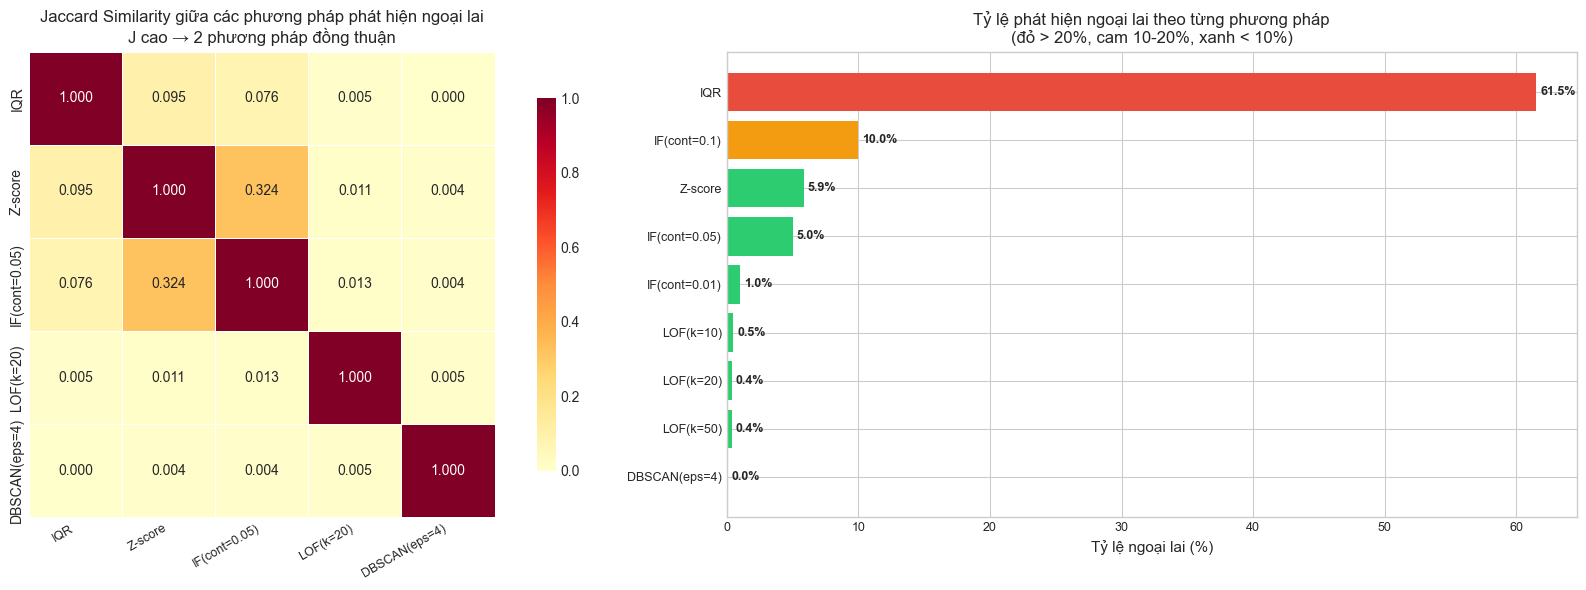


Nhận xét Jaccard:
  • IQR & Z-score: J thường cao → đều dùng ngưỡng thống kê, đồng thuận
  • IF & LOF: J vừa → đều model-based nhưng cơ chế khác nhau
  • DBSCAN vs còn lại: J thấp → clustering khác biệt với threshold-based


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# JACCARD SIMILARITY GIỮA CÁC PHƯƠNG PHÁP
# ══════════════════════════════════════════════════════════════════════════════
# Chọn 6 phương pháp chính (1 cấu hình đại diện mỗi loại)
main_methods = ['IQR', 'Z-score', 'IF(cont=0.05)', 'LOF(k=20)', 'DBSCAN(eps=4)']

def jaccard(s1, s2):
    """Tính Jaccard similarity giữa 2 tập."""
    union = len(s1 | s2)
    return len(s1 & s2) / union if union > 0 else 1.0

# Tính Jaccard matrix
jac_data = {}
for m1 in main_methods:
    jac_data[m1] = {}
    for m2 in main_methods:
        jac_data[m1][m2] = round(jaccard(outlier_sets[m1], outlier_sets[m2]), 3)

jac_df = pd.DataFrame(jac_data, index=main_methods, columns=main_methods)

print('═' * 80)
print('  JACCARD SIMILARITY MATRIX (giao / hợp)')
print('  J = 1 → phát hiện giống nhau hoàn toàn | J = 0 → hoàn toàn khác')
print('═' * 80)
print(jac_df.to_string())

# ── Heatmap Jaccard ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Jaccard heatmap
sns.heatmap(jac_df, annot=True, fmt='.3f', cmap='YlOrRd', vmin=0, vmax=1,
            ax=axes[0], linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
axes[0].set_title('Jaccard Similarity giữa các phương pháp phát hiện ngoại lai\n'
                   'J cao → 2 phương pháp đồng thuận', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right', fontsize=9)

# Bar chart so sánh tỷ lệ phát hiện
methods_sorted = sorted(outlier_rates.items(), key=lambda x: x[1], reverse=True)
m_names = [m[0] for m in methods_sorted]
m_rates = [m[1] * 100 for m in methods_sorted]
colors_bar = ['#e74c3c' if r > 20 else ('#f39c12' if r > 10 else '#2ecc71') for r in m_rates]
bars = axes[1].barh(m_names[::-1], m_rates[::-1], color=colors_bar[::-1])
axes[1].set_xlabel('Tỷ lệ ngoại lai (%)', fontsize=11)
axes[1].set_title('Tỷ lệ phát hiện ngoại lai theo từng phương pháp\n'
                   '(đỏ > 20%, cam 10-20%, xanh < 10%)', fontsize=12)
for bar, val in zip(bars, m_rates[::-1]):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
axes[1].tick_params(labelsize=9)

plt.tight_layout()
plt.show()

print('\nNhận xét Jaccard:')
print('  • IQR & Z-score: J thường cao → đều dùng ngưỡng thống kê, đồng thuận')
print('  • IF & LOF: J vừa → đều model-based nhưng cơ chế khác nhau')
print('  • DBSCAN vs còn lại: J thấp → clustering khác biệt với threshold-based')

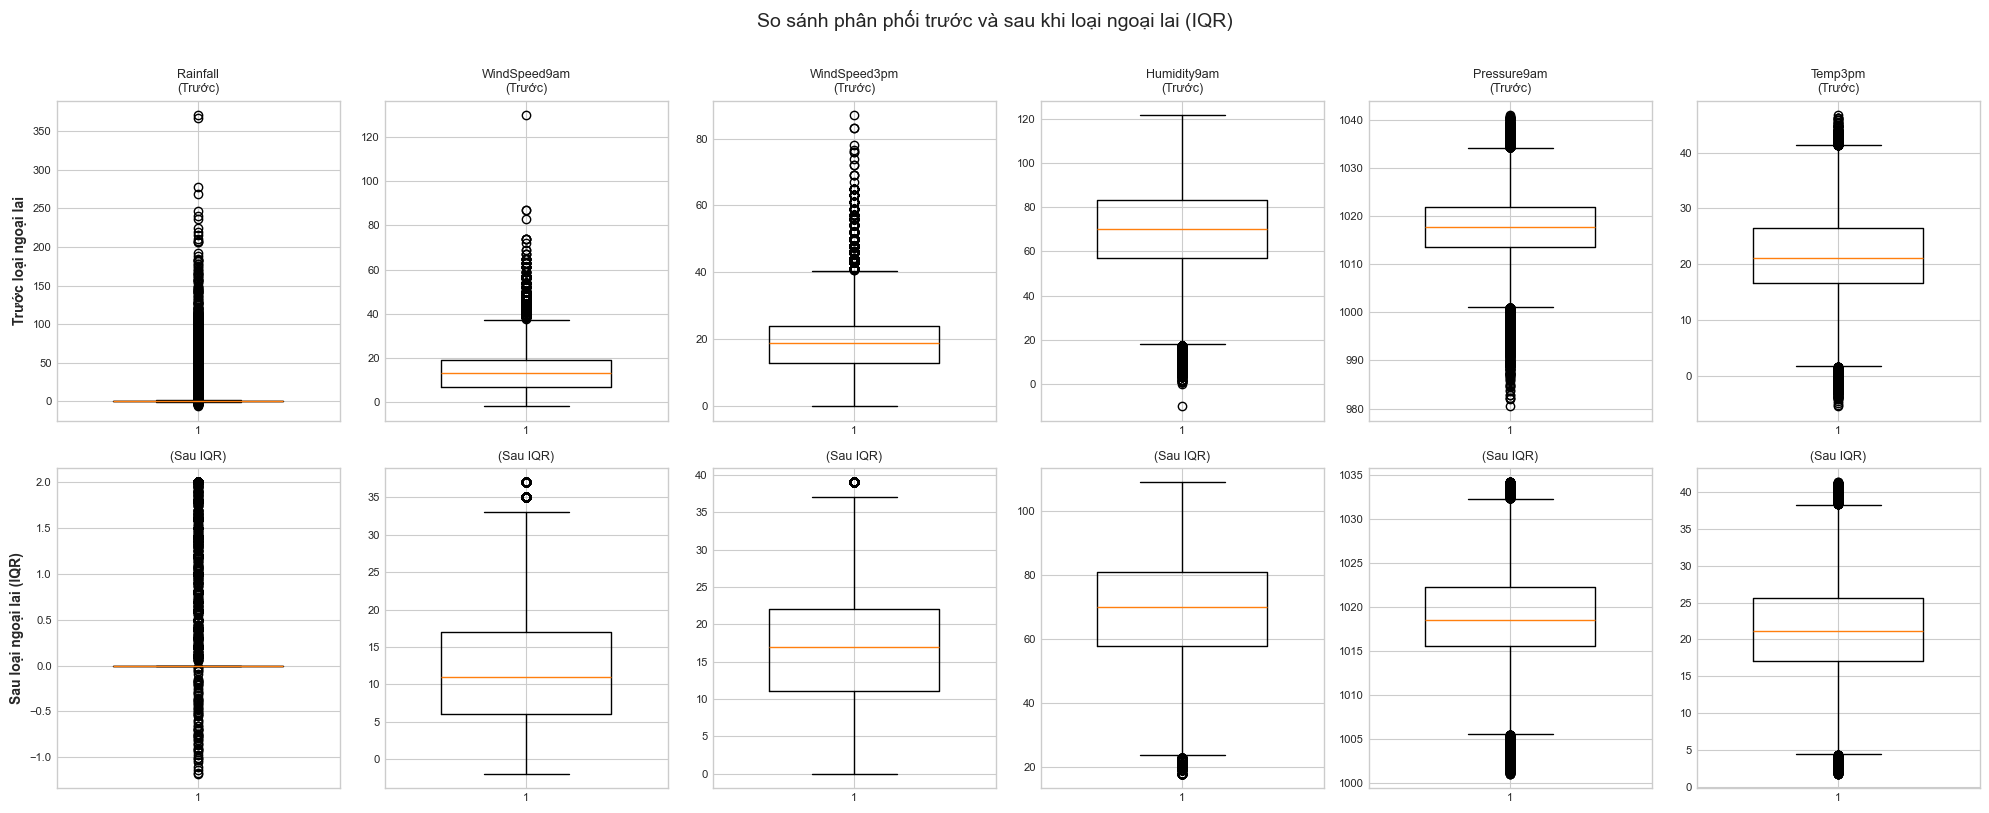

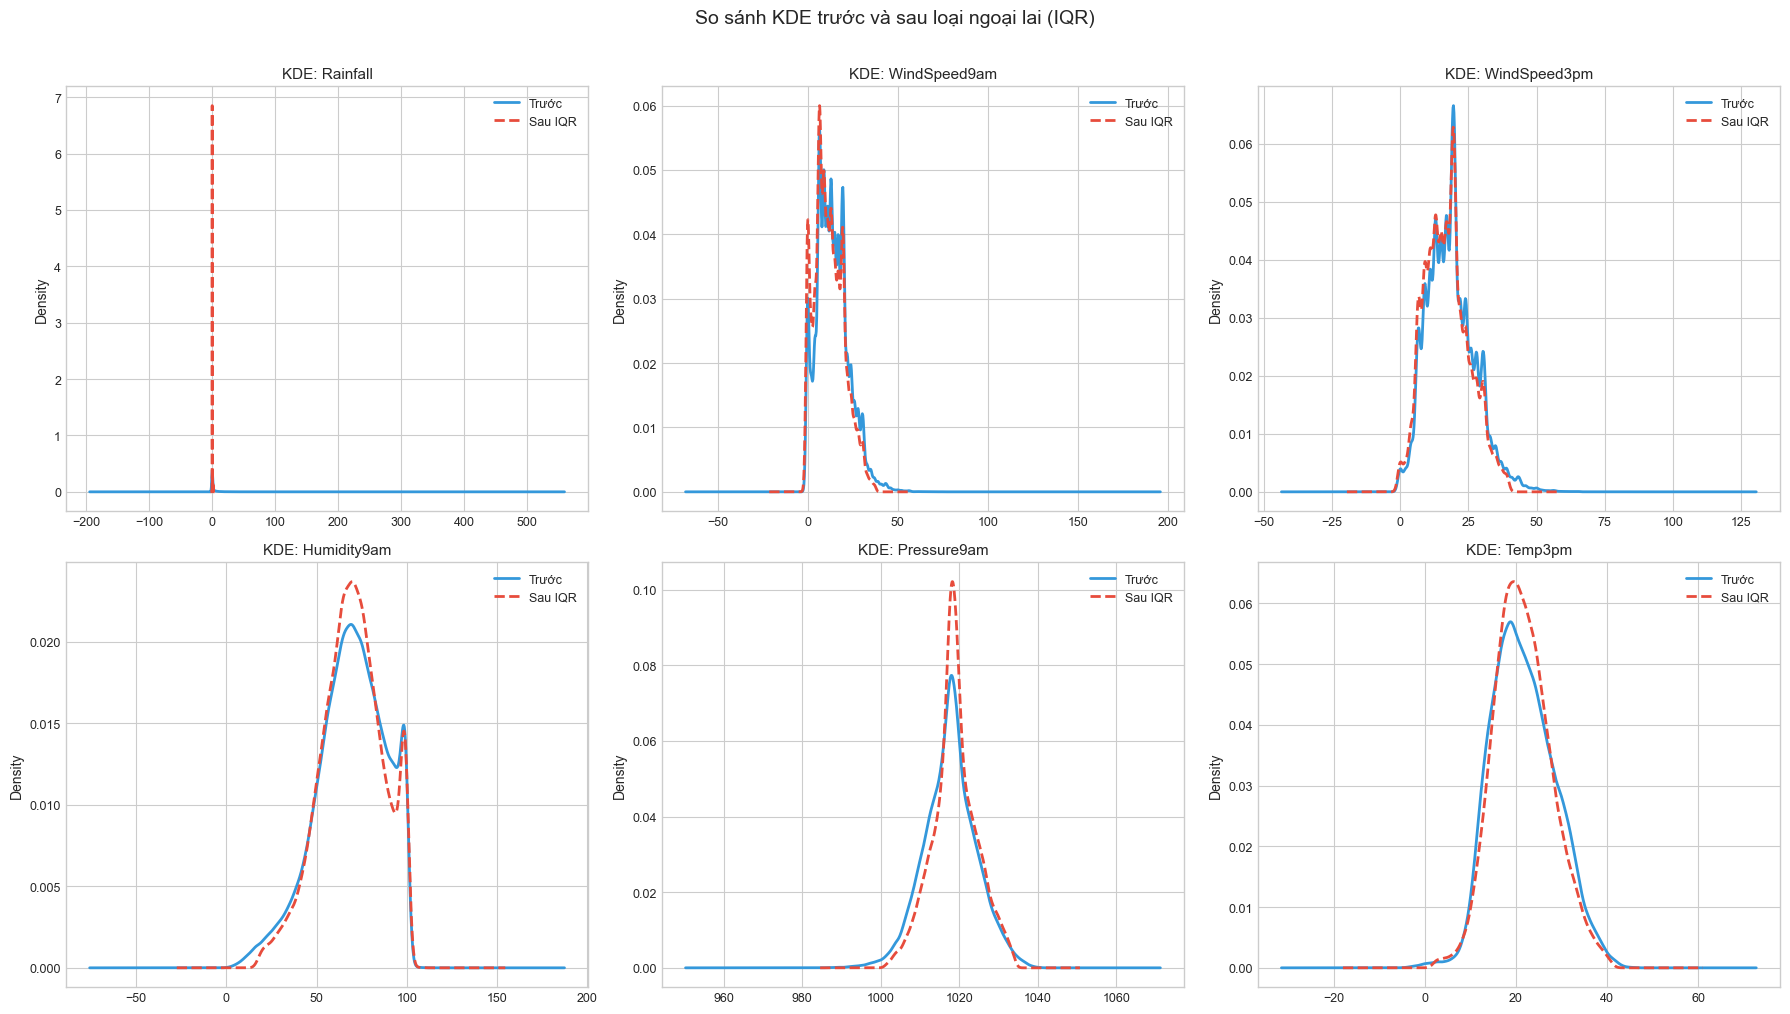

═══════════════════════════════════════════════════════════════════════════
  KS-TEST: SO SÁNH PHÂN PHỐI TRƯỚC VÀ SAU LOẠI NGOẠI LAI (IQR)
  H₀: Hai phân phối giống nhau | H₁: Khác nhau có ý nghĩa thống kê
═══════════════════════════════════════════════════════════════════════════
Cột                     KS stat        p-value             Kết luận   Thay đổi mean
────────────────────────────────────────────────────────────────────────────────
MinTemp                  0.0698       0.000000   Khác biệt (p<0.05)         -10.41%
MaxTemp                  0.0412       0.000000   Khác biệt (p<0.05)          -0.99%
Rainfall                 0.1836       0.000000   Khác biệt (p<0.05)         -93.28%
Evaporation              0.1985       0.000000   Khác biệt (p<0.05)          -8.96%
Sunshine                 0.2183       0.000000   Khác biệt (p<0.05)          +5.79%
WindGustSpeed            0.0718       0.000000   Khác biệt (p<0.05)          -7.46%
WindSpeed9am             0.0837       0.000000   

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# ĐÁNH GIÁ TÁC ĐỘNG CỦA LOẠI NGOẠI LAI: BOXPLOT + KDE + KS TEST
# ══════════════════════════════════════════════════════════════════════════════

# ── 1. Boxplot trước/sau loại ngoại lai IQR ──────────────────────────────────
rep_cols = ['Rainfall', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
            'Pressure9am', 'Temp3pm']
df_no_iqr = df_num[~iqr_mask].copy()

fig, axes = plt.subplots(2, len(rep_cols), figsize=(20, 8), sharey=False)

for j, col in enumerate(rep_cols):
    # Trước
    axes[0, j].boxplot(df_num[col].dropna().values, widths=0.6)
    axes[0, j].set_title(f'{col}\n(Trước)', fontsize=9)
    axes[0, j].tick_params(labelsize=8)
    # Sau
    axes[1, j].boxplot(df_no_iqr[col].dropna().values, widths=0.6)
    axes[1, j].set_title(f'(Sau IQR)', fontsize=9)
    axes[1, j].tick_params(labelsize=8)

axes[0, 0].set_ylabel('Trước loại ngoại lai', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Sau loại ngoại lai (IQR)', fontsize=10, fontweight='bold')
fig.suptitle('So sánh phân phối trước và sau khi loại ngoại lai (IQR)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── 2. KDE overlay trước/sau ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for j, col in enumerate(rep_cols):
    ax = axes_flat[j]
    df_num[col].dropna().plot.kde(ax=ax, label='Trước', color='#3498db', linewidth=2)
    df_no_iqr[col].dropna().plot.kde(ax=ax, label='Sau IQR', color='#e74c3c', linewidth=2, linestyle='--')
    ax.set_title(f'KDE: {col}', fontsize=11)
    ax.legend(fontsize=9)
    ax.tick_params(labelsize=9)

plt.suptitle('So sánh KDE trước và sau loại ngoại lai (IQR)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── 3. KS-test: so sánh phân phối trước/sau loại ngoại lai ──────────────────
print('═' * 75)
print('  KS-TEST: SO SÁNH PHÂN PHỐI TRƯỚC VÀ SAU LOẠI NGOẠI LAI (IQR)')
print('  H₀: Hai phân phối giống nhau | H₁: Khác nhau có ý nghĩa thống kê')
print('═' * 75)
print(f'{"Cột":<20} {"KS stat":>10} {"p-value":>14} {"Kết luận":>20} {"Thay đổi mean":>15}')
print('─' * 80)

ks_results = []
for col in outlier_cols:
    before = df_num[col].dropna().values
    after  = df_no_iqr[col].dropna().values
    ks_stat, p_val = ks_2samp(before, after)
    mean_change = ((after.mean() - before.mean()) / before.mean() * 100) if before.mean() != 0 else 0
    sig = 'Khác biệt (p<0.05)' if p_val < 0.05 else 'Không khác biệt'
    print(f'{col:<20} {ks_stat:>10.4f} {p_val:>14.6f} {sig:>20} {mean_change:>+14.2f}%')
    ks_results.append({'Column': col, 'KS_stat': ks_stat, 'p_value': p_val, 
                        'Significant': p_val < 0.05, 'Mean_change_%': round(mean_change, 2)})

ks_df = pd.DataFrame(ks_results)
n_sig = ks_df['Significant'].sum()
print('─' * 80)
print(f'  → {n_sig}/{len(outlier_cols)} cột có phân phối thay đổi đáng kể sau loại ngoại lai')

# ── 4. Tổng kết và quyết định ────────────────────────────────────────────────
print(f'''
══════════════════════════════════════════════════════════════════════════════
  TỔNG KẾT PHÁT HIỆN VÀ XỬ LÝ NGOẠI LAI
══════════════════════════════════════════════════════════════════════════════
  PHÁT HIỆN:
  ─────────
  • IQR phát hiện {len(outlier_sets['IQR']):,} ngoại lai ({outlier_rates['IQR']:.1%})
  • Z-score phát hiện {len(outlier_sets['Z-score']):,} ngoại lai ({outlier_rates['Z-score']:.1%})
  • IF (cont=0.05): {len(outlier_sets['IF(cont=0.05)']):,} ({outlier_rates['IF(cont=0.05)']:.1%})
  • LOF (k=20): {len(outlier_sets['LOF(k=20)']):,} ({outlier_rates['LOF(k=20)']:.1%})

  OVERLAP (Jaccard):
  ──────────────────
  • IQR ∩ Z-score: J = {jac_df.loc['IQR','Z-score']:.3f}
  • IQR ∩ IF: J = {jac_df.loc['IQR','IF(cont=0.05)']:.3f}
  • IQR ∩ LOF: J = {jac_df.loc['IQR','LOF(k=20)']:.3f}

  TÁC ĐỘNG (KS-test):
  ────────────────────
  • {{n_sig}}/{len(outlier_cols)} cột thay đổi phân phối đáng kể sau loại IQR outlier
  • Các cột Rainfall, WindSpeed bị ảnh hưởng nhiều nhất (phân phối lệch)

  QUYẾT ĐỊNH:
  ────────────
  → KHÔNG loại bỏ hàng ngoại lai (mất quá nhiều mẫu)
  → Sử dụng kỹ thuật robust ở bước chuẩn hóa (RobustScaler)
  → Nếu cần, dùng winsorization hoặc log-transform cho cột lệch nặng
══════════════════════════════════════════════════════════════════════════════
''')